###Project: Build a Machine Learning model that learns the relationship between electrical measurements (Voltage, Sub-meter readings, time, etc.) and household electricity usage.

###What I am going to do: Train the model using historical data so it can estimate/predict the house's Global Active Power (total electricity consumption) from the given input features.

In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/DataSet/household_power_consumption.txt")

In [ ]:
df.head()

,Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3
0,16/12/2006;17:24:00;4.216;0.418;234.840;18.400...
1,16/12/2006;17:25:00;5.360;0.436;233.630;23.000...
2,16/12/2006;17:26:00;5.374;0.498;233.290;23.000...
3,16/12/2006;17:27:00;5.388;0.502;233.740;23.000...
4,16/12/2006;17:28:00;3.666;0.528;235.680;15.800...


Here the detaset on text file and the column name are in one column. we have to separate all this!

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/DataSet/household_power_consumption.txt",
    sep=';',
    na_values='?',
    low_memory=False
)

In [ ]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.shape

(2075259, 9)

In [ ]:
## Data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


##EDA

In [ ]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


In [ ]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


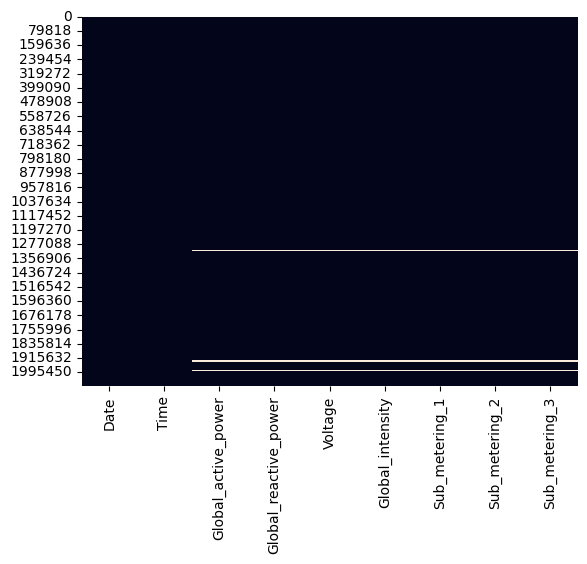

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

### Tring to find outlayer.

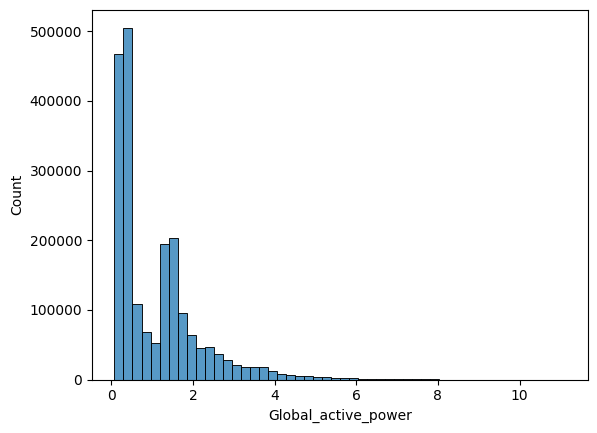

In [ ]:
sns.histplot(df['Global_active_power'], bins=50)
plt.show()

##  we have to calculate the hour.so we have to marge the two columns-'Time','Date' new-'DateTime'

In [ ]:
df["DateTime"]=pd.to_datetime(df["Date"]+ " "+df["Time"],errors='coerce')

/tmp/ipykernel_2012/1900263691.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["DateTime"]=pd.to_datetime(df["Date"]+ " "+df["Time"],errors='coerce')


In [ ]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### visualize time with power changes

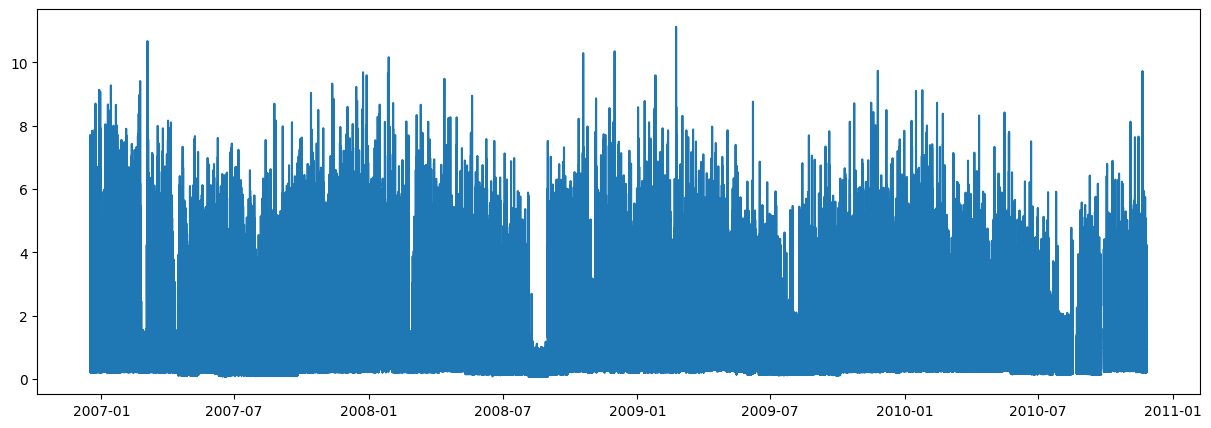

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['DateTime'],
         df['Global_active_power'])
plt.show()

### now we have to drop the Null value accroding to the 'DateTime'coloumn.It is our target column so if in this coloumn are stay null value the coloumn will droped.

In [ ]:
df.dropna(subset=['DateTime'],inplace=True)

### We need to separate the days and hours by calculating.

In [ ]:
df['hour']=df['DateTime'].dt.hour
df['day']=df['DateTime'].dt.dayofweek

In [ ]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,hour,day
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,5
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,5
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,5
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,5
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,5


### Try to see hour useful or not

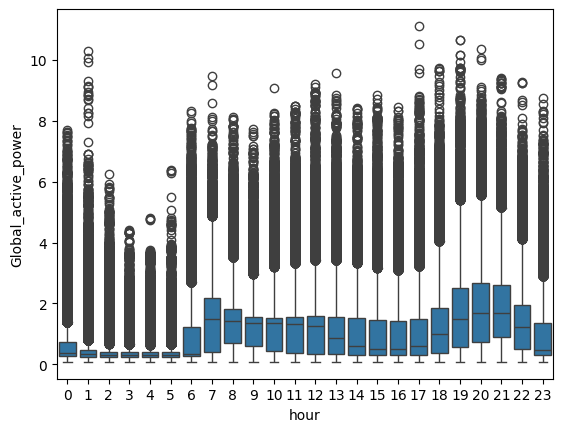

In [ ]:
sns.boxplot(
    x=df['hour'],
    y=df['Global_active_power']
)
plt.show()

### Days vs power

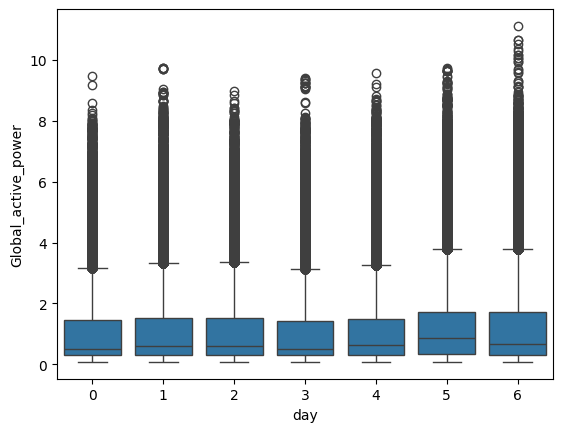

In [ ]:
sns.boxplot(
    x=df['day'],
    y=df['Global_active_power']
)
plt.show()

### Need to drop the Null value form the features

In [ ]:
cols= ['Global_active_power','Voltage',	'Sub_metering_1', 'Sub_metering_2','Sub_metering_3']


In [ ]:
df.dropna(subset=cols,inplace=True)

In [ ]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
DateTime,0


### Try to find the corellation from the features

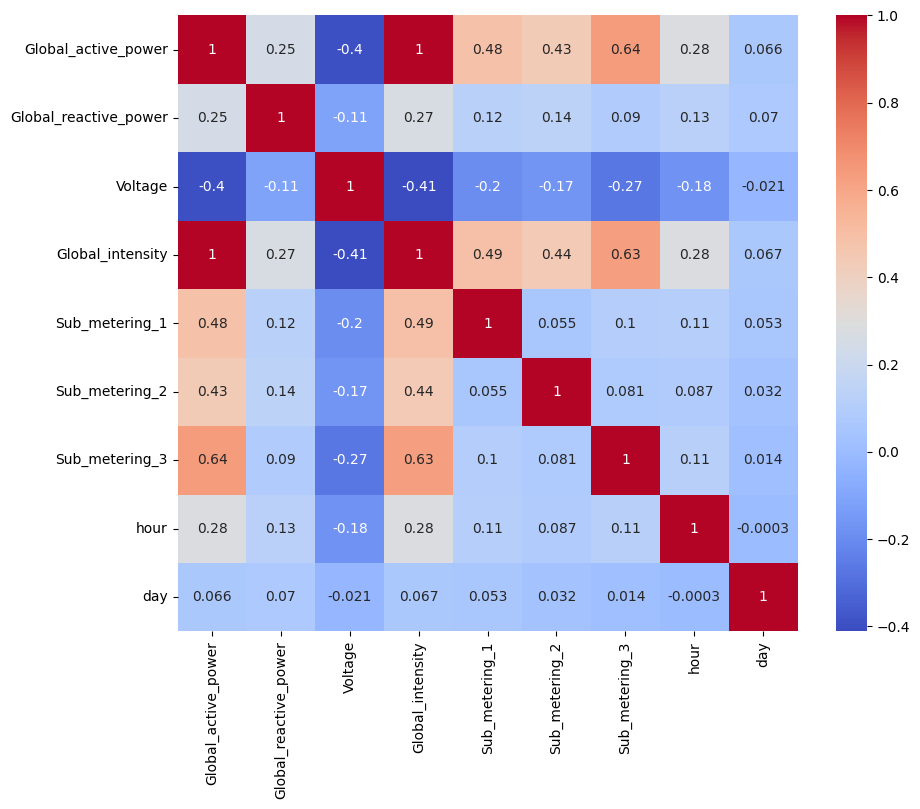

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [ ]:
x = df[['hour','day','Voltage','Sub_metering_1',	'Sub_metering_2',	'Sub_metering_3']]
y=df['Global_active_power']


In [ ]:
x.shape,y.shape

((2049280, 6), (2049280,))

In [ ]:
from numpy import shape
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
shape(x_train),shape(y_test)

((1639424, 6), (409856,))

In [ ]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
x_train_scaled = st.fit_transform(x_train)
x_test_scaled= st.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()


In [ ]:
model = lr.fit(x_train_scaled,y_train)

In [ ]:
data_pred = model.predict(x_test_scaled)

In [ ]:
data_pred

array([1.63556476, 0.75117664, 0.7697732 , ..., 0.3750078 , 1.87177123,
       2.61595108])

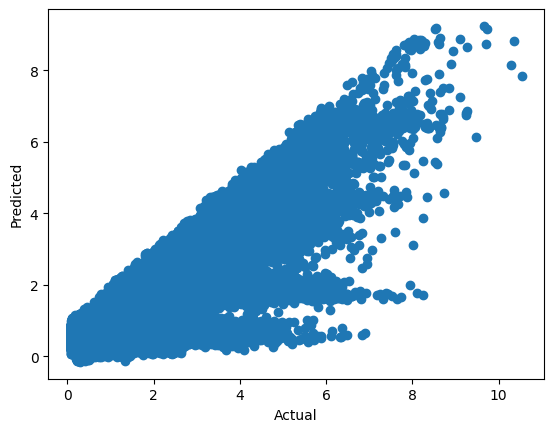

In [ ]:
plt.scatter(
    y_test,
    data_pred
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse = mean_squared_error(data_pred, y_test)
mse

0.2792291060173848

In [ ]:
r2= r2_score(data_pred, y_test)


In [ ]:
print(round(mse,3))

0.279


In [ ]:
print(round(r2,3))

0.668


In [ ]:
custom_values = [[12,5,240,12,5,18]]

In [ ]:
cv=st.transform(custom_values)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
cv

array([[ 0.07169341,  1.00611978, -0.25973621,  1.76896111,  0.63744914,
         1.3682235 ]])

In [ ]:
pred=model.predict(cv)
print(pred)

[2.85448103]
